In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load dataset (Make sure the .csv file is in the same folder as your notebook)
df = pd.read_csv('Symptom2Disease.csv')
df = df[['label', 'text']] # Keep only relevant columns

print(f"Total Records: {len(df)}")
df.head()

Total Records: 1200


,label,text
0,Psoriasis,I have been experiencing a skin rash on my arm...
1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,Psoriasis,I have been experiencing joint pain in my fing...
3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,Psoriasis,"My nails have small dents or pits in them, and..."


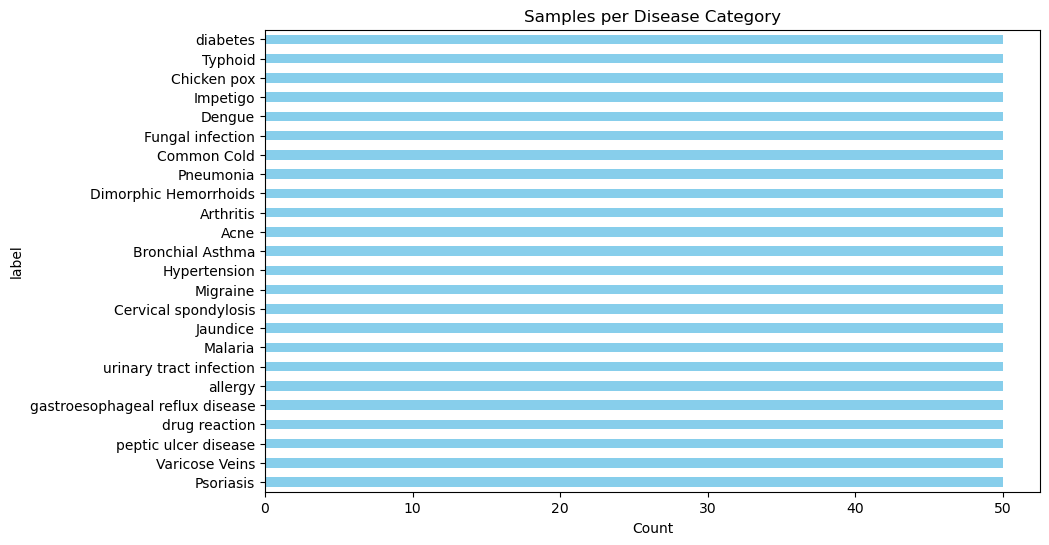

In [3]:
plt.figure(figsize=(10, 6))
df['label'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Samples per Disease Category')
plt.xlabel('Count')
plt.show()

In [4]:
# 1. Encode labels (Disease Names -> Numbers)
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# 2. Vectorize symptoms (Natural Language -> Numbers)
# We use 'english' stop words to remove common words like 'the', 'is', 'a'
tfidf = TfidfVectorizer(stop_words='english', max_features=1500)
X = tfidf.fit_transform(df['text']).toarray()
y = df['label_enc']

print(f"Vocabulary Size: {len(tfidf.vocabulary_)}")

Vocabulary Size: 1367


In [5]:
# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the classifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


Model Accuracy: 95.83%


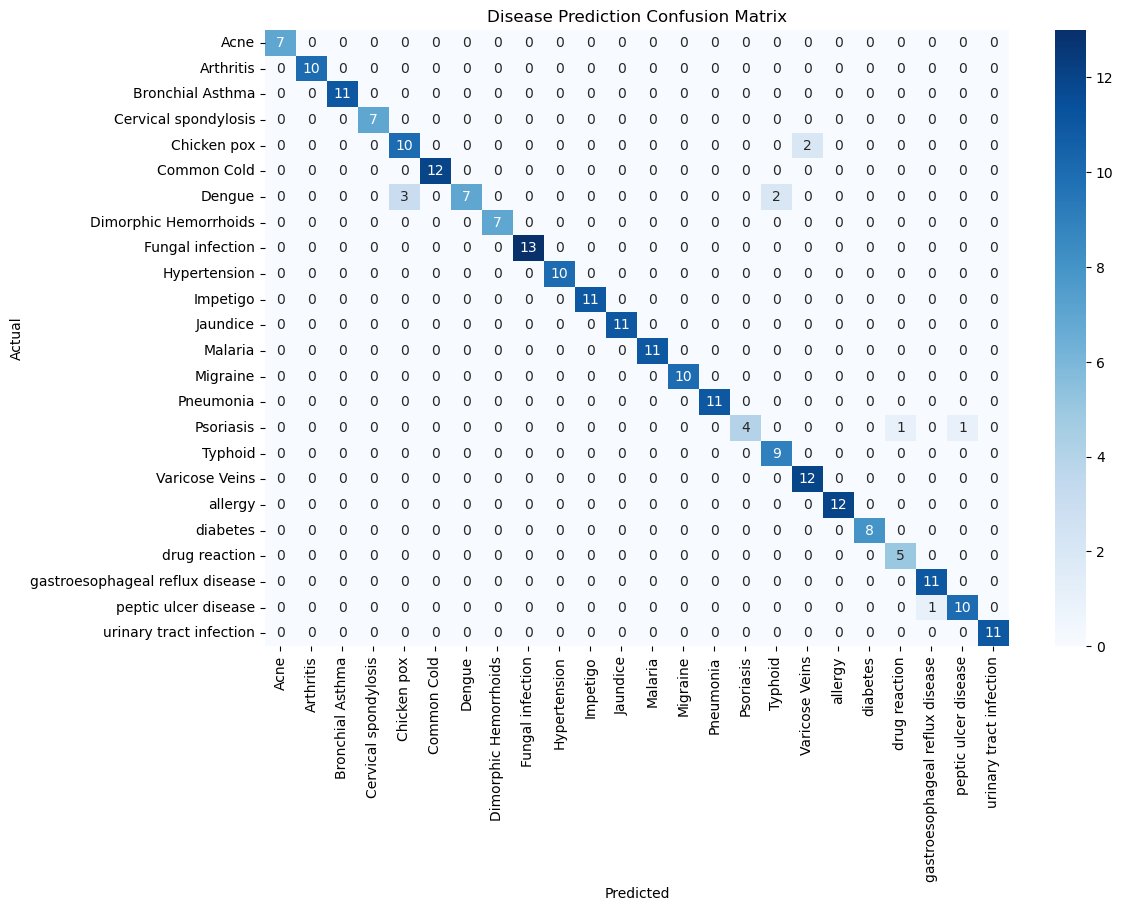

In [6]:
y_pred = model.predict(X_test)

# Show accuracy
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Confusion Matrix to see where the model gets confused
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Disease Prediction Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Create a folder named 'models' if it doesn't exist
import os
if not os.path.exists('models'):
    os.makedirs('models')

model_assets = {
    'model': model,
    'tfidf': tfidf,
    'label_encoder': le
}

with open('models/symptom_model.pkl', 'wb') as f:
    pickle.dump(model_assets, f)

print("Model assets saved successfully in 'models/symptom_model.pkl'")

Model assets saved successfully in 'models/symptom_model.pkl'


In [8]:
# Function to predict disease from a text input
def predict_symptom(text):
    # 1. Transform the input text using the trained TF-IDF vectorizer
    text_vector = tfidf.transform([text]).toarray()
    
    # 2. Predict the numerical label
    prediction_enc = model.predict(text_vector)
    
    # 3. Inverse transform to get the actual disease name
    disease_name = le.inverse_transform(prediction_enc)
    
    return disease_name[0]

# --- LIVE TEST CASES ---
test_symptoms = [
    "I have high fever, chills, and a severe headache.",
    "My skin is very itchy and I have red rashes all over my arm.",
    "I have a persistent cough and I feel short of breath."
]

print("--- Testing Saved Model Logic ---")
for s in test_symptoms:
    result = predict_symptom(s)
    print(f"Symptom: {s}")
    print(f"Predicted Disease: {result}\n")

--- Testing Saved Model Logic ---
Symptom: I have high fever, chills, and a severe headache.
Predicted Disease: Dengue

Symptom: My skin is very itchy and I have red rashes all over my arm.
Predicted Disease: Psoriasis

Symptom: I have a persistent cough and I feel short of breath.
Predicted Disease: Bronchial Asthma

